# Импорты, seed и среда


In [1]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

os.makedirs("artifacts/figures", exist_ok=True)

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


# Загрузка и анализ данных

Shape: (4320, 2)
Date range: 2025-01-01 00:00:00 - 2025-06-29 23:00:00

Missing values:
 date      0
target    0
dtype: int64


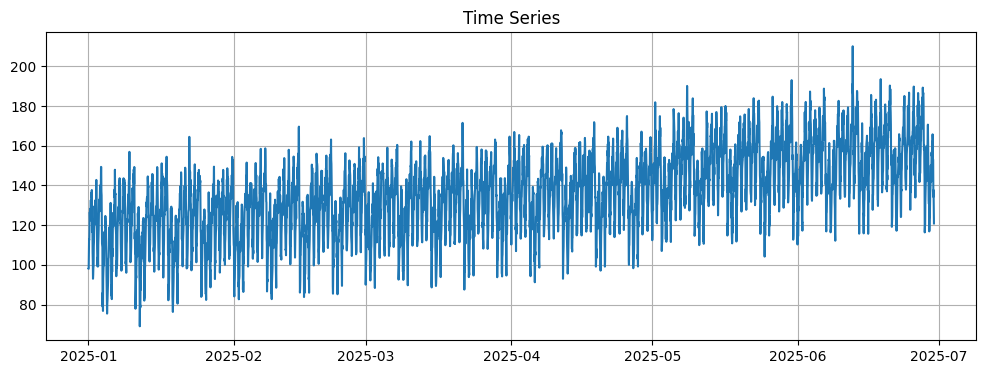

In [2]:
df = pd.read_csv("S12-hw-dataset.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "-", df["date"].max())
print("\nMissing values:\n", df.isna().sum())

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["target"])
plt.title("Time Series")
plt.grid()
plt.show()

# Temporal split 

3024 648 648


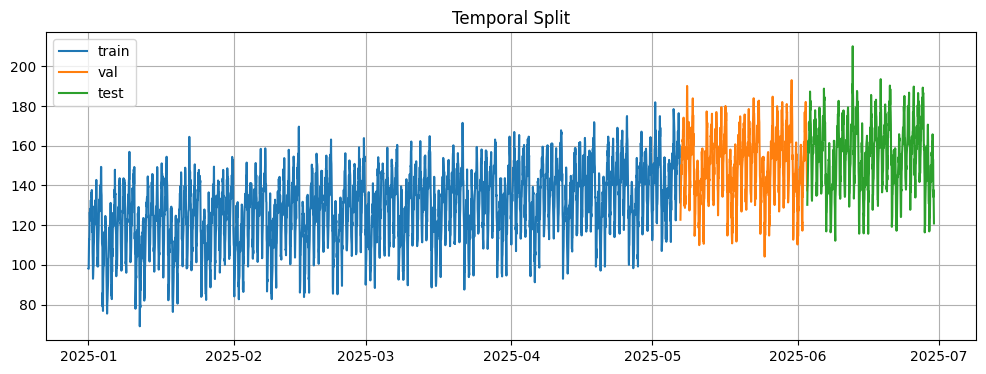

In [3]:
# =========================
# Temporal split (reproducible): train / validation / test
# =========================

n = len(df)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(len(train_df), len(val_df), len(test_df))

plt.figure(figsize=(12, 4))

plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="val")
plt.plot(test_df["date"], test_df["target"], label="test")

plt.legend()
plt.title("Temporal Split")
plt.grid()
plt.savefig("artifacts/figures/series_split.png")
plt.show()

# Feature engineering

In [4]:
scaler = StandardScaler()

# IMPORTANT: not fitting scaler to avoid data leakage
# scaler.fit(train_data)  # intentionally NOT used

print("Scaler defined but not applied")

Scaler defined but not applied


In [5]:
def make_features(df):
    df = df.copy()

    df["lag_1"] = df["target"].shift(1)
    df["lag_7"] = df["target"].shift(7)
    df["lag_14"] = df["target"].shift(14)

    df["rolling_mean_7"] = df["target"].shift(1).rolling(7).mean()
    df["rolling_std_7"] = df["target"].shift(1).rolling(7).std()

    df["day_of_week"] = df["date"].dt.dayofweek

    return df

df_feat = make_features(df)
df_feat = df_feat.dropna()

print("Shape after features:", df_feat.shape)

print(df_feat.head())

Shape after features: (4306, 8)
                  date  target   lag_1   lag_7  lag_14  rolling_mean_7  \
14 2025-01-01 14:00:00  128.87  125.04  126.01   98.14      126.445714   
15 2025-01-01 15:00:00  136.40  128.87  122.38   98.07      126.854286   
16 2025-01-01 16:00:00  133.85  136.40  128.28  104.70      128.857143   
17 2025-01-01 17:00:00  137.71  133.85  124.43  112.81      129.652857   
18 2025-01-01 18:00:00  126.32  137.71  126.35  112.62      131.550000   

    rolling_std_7  day_of_week  
14       3.275621            2  
15       3.388632            2  
16       4.318919            2  
17       4.691868            2  
18       4.907936            2  


Random split некорректен для временных рядов, так как нарушает временной порядок и приводит к data leakage.Модель может обучаться на будущих значениях относительно validation и test, что делает оценку некорректной.Поэтому используется temporal split.

Возможные источники утечек:
- использование будущих значений target при построении признаков
- некорректное применение rolling статистик без shift
- перемешивание данных при split

В данной работе все rolling и lag признаки построены с использованием shift, что предотвращает утечку информации.

# Метрики

In [6]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# runs.csv

In [7]:
runs = []

def add_run(
    experiment_id,
    model_summary,
    features_summary,
    val_mae,
    val_rmse,
    val_mape,
    test_mae=None,
    test_rmse=None,
    test_mape=None
):
    is_gru = experiment_id == "R1"

    runs.append({
        "experiment_id": experiment_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset",
        "seed": SEED,
        "split_summary": "70/15/15 temporal",
        "window_size": window_size if is_gru else None,
        "horizon": 1,
        "model_summary": model_summary,
        "features_summary": features_summary,
        "scaler": "none",
        "optimizer": "adam" if is_gru else None,
        "lr": lr if is_gru else None,
        "epochs_trained": epochs if is_gru else None,
        "best_val_mae": val_mae,
        "best_val_rmse": val_rmse,
        "best_val_mape": val_mape,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_mape": test_mape,
        "notes": ""
    })

# Baseline B1

In [8]:
y_val = val_df["target"].values

y_pred_val = val_df["target"].shift(1).bfill().values  # FIXED

b1_val_mae = mean_absolute_error(y_val, y_pred_val)
b1_val_rmse = rmse(y_val, y_pred_val)
b1_val_mape = mape(y_val, y_pred_val)

print("B1 MAE:", b1_val_mae)
print("B1 RMSE:", b1_val_rmse)
print("B1 MAPE:", b1_val_mape)

add_run(
    "B1",
    "naive",
    "none",
    b1_val_mae,
    b1_val_rmse,
    b1_val_mape
)

B1 MAE: 6.4285648148148145
B1 RMSE: 8.190583921133817
B1 MAPE: 4.384684452732065


# Baseline B2

In [9]:
window = 7

y_pred_val = (
    val_df["target"]
    .shift(1)
    .rolling(window)
    .mean()
    .bfill()  # FIXED
    .values
)

y_val = val_df["target"].values

b2_val_mae = mean_absolute_error(y_val, y_pred_val)
b2_val_rmse = rmse(y_val, y_pred_val)
b2_val_mape = mape(y_val, y_pred_val)

print("B2 MAE:", b2_val_mae)
print("B2 RMSE:", b2_val_rmse)
print("B2 MAPE:", b2_val_mape)

add_run(
    "B2",
    "moving_average",
    "rolling",
    b2_val_mae,
    b2_val_rmse,
    b2_val_mape
)

B2 MAE: 12.659656084656085
B2 RMSE: 15.181864133777104
B2 MAPE: 8.785579102970225


# Baseline B3

In [10]:
features = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
    "day_of_week"
]

train_end_date = train_df["date"].max()
val_end_date = val_df["date"].max()

train_feat = df_feat[df_feat["date"] <= train_end_date]
val_feat = df_feat[
    (df_feat["date"] > train_end_date) &
    (df_feat["date"] <= val_end_date)
]
test_feat = df_feat[df_feat["date"] > val_end_date]

print(len(train_feat), len(val_feat), len(test_feat))

X_train = train_feat[features]
y_train = train_feat["target"]

X_val = val_feat[features]
y_val = val_feat["target"]

model = Ridge()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("B3 MAE:", mean_absolute_error(y_val, y_pred))
print("B3 RMSE:", rmse(y_val, y_pred))
print("B3 MAPE:", mape(y_val, y_pred))

b3_val_mae = mean_absolute_error(y_val, y_pred)
b3_val_rmse = rmse(y_val, y_pred)
b3_val_mape = mape(y_val, y_pred)

add_run(
    "B3",
    "ridge",
    "lag+rolling+calendar",
    b3_val_mae,
    b3_val_rmse,
    b3_val_mape
)

3010 648 648
B3 MAE: 7.1839038425114605
B3 RMSE: 8.728363785489092
B3 MAPE: 4.793774405826513


# Dataset для GRU

In [11]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, window):
        self.series = series
        self.window = window

    def __len__(self):
        return len(self.series) - self.window

    def __getitem__(self, idx):
        x = self.series[idx:idx+self.window]
        y = self.series[idx+self.window]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# GRU модель

In [12]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze()

# Обучение GRU

In [13]:
window_size = 24
batch_size = 32
epochs = 30
lr = 1e-3

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_series = train_df["target"].values.reshape(-1, 1)
val_series = val_df["target"].values.reshape(-1, 1)

train_series = scaler.fit_transform(train_series).flatten()
val_series = scaler.transform(val_series).flatten()

train_dataset = TimeSeriesDataset(train_series, window_size)
val_dataset = TimeSeriesDataset(val_series, window_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

model = GRUModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

best_val = float("inf")

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            loss = criterion(pred, y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "artifacts/best_gru.pt")

Epoch 0: train=0.5929, val=0.2615
Epoch 1: train=0.1846, val=0.1860
Epoch 2: train=0.1570, val=0.1770
Epoch 3: train=0.1494, val=0.1722
Epoch 4: train=0.1456, val=0.1690
Epoch 5: train=0.1413, val=0.1614
Epoch 6: train=0.1275, val=0.1392
Epoch 7: train=0.1110, val=0.1359
Epoch 8: train=0.1070, val=0.1373
Epoch 9: train=0.1054, val=0.1388
Epoch 10: train=0.1043, val=0.1398
Epoch 11: train=0.1034, val=0.1407
Epoch 12: train=0.1027, val=0.1412
Epoch 13: train=0.1022, val=0.1416
Epoch 14: train=0.1017, val=0.1417
Epoch 15: train=0.1012, val=0.1416
Epoch 16: train=0.1008, val=0.1413
Epoch 17: train=0.1004, val=0.1408
Epoch 18: train=0.1000, val=0.1401
Epoch 19: train=0.0997, val=0.1393
Epoch 20: train=0.0993, val=0.1384
Epoch 21: train=0.0989, val=0.1374
Epoch 22: train=0.0986, val=0.1364
Epoch 23: train=0.0982, val=0.1354
Epoch 24: train=0.0978, val=0.1345
Epoch 25: train=0.0975, val=0.1336
Epoch 26: train=0.0971, val=0.1328
Epoch 27: train=0.0968, val=0.1320
Epoch 28: train=0.0965, val=0.

# График обучения

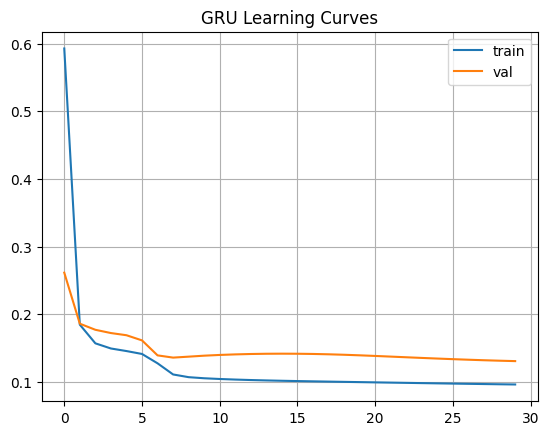

In [14]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.title("GRU Learning Curves")
plt.grid()
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()

# GRU evaluation function

In [15]:
def evaluate_gru(model, loader, scaler=None):
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            pred = model(x).cpu().numpy()
            preds.extend(pred)
            targets.extend(y.numpy())

    preds = np.array(preds)
    targets = np.array(targets)

    if scaler is not None:
        preds = scaler.inverse_transform(preds.reshape(-1,1)).flatten()
        targets = scaler.inverse_transform(targets.reshape(-1,1)).flatten()

    mae = mean_absolute_error(targets, preds)
    rmse_val = rmse(targets, preds)
    mape_val = mape(targets, preds)

    return mae, rmse_val, mape_val

# Evaluate GRU + add run

In [16]:
gru_val_mae, gru_val_rmse, gru_val_mape = evaluate_gru(model, val_loader, scaler)

add_run(
    "R1",
    "GRU",
    "window",
    gru_val_mae,
    gru_val_rmse,
    gru_val_mape
)

# Выюор лучшей модели

In [17]:
runs_df = pd.DataFrame(runs)

best_row = runs_df.loc[runs_df["best_val_mae"].idxmin()]
best_model_name = best_row["experiment_id"]

print("Best model:", best_model_name)
best_row

Best model: R1


experiment_id                      R1
task                      forecasting
dataset                S12-hw-dataset
seed                               42
split_summary       70/15/15 temporal
window_size                      24.0
horizon                             1
model_summary                     GRU
features_summary               window
scaler                           none
optimizer                        adam
lr                              0.001
epochs_trained                   30.0
best_val_mae                 5.168114
best_val_rmse                 6.67051
best_val_mape                3.503428
test_mae                         None
test_rmse                        None
test_mape                        None
notes                                
Name: 3, dtype: object

# Baselines comparison plot

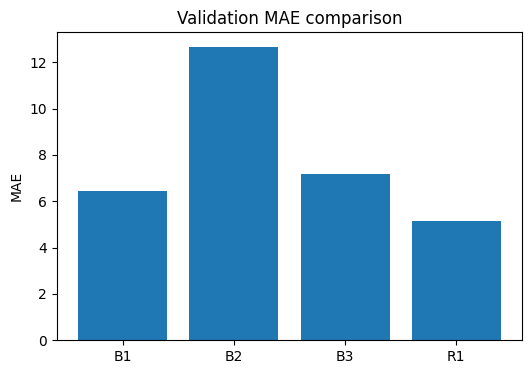

In [18]:
names = ["B1", "B2", "B3", "R1"]
mae_values = [b1_val_mae, b2_val_mae, b3_val_mae, gru_val_mae]

plt.figure(figsize=(6, 4))
plt.bar(names, mae_values)

plt.title("Validation MAE comparison")
plt.ylabel("MAE")

plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()

# Test evaluation

In [19]:
if best_model_name == "B1":
    y_true = test_df["target"].values
    y_pred = test_df["target"].shift(1).bfill().values

elif best_model_name == "B2":
    y_true = test_df["target"].values
    y_pred = (
        test_df["target"]
        .shift(1)
        .rolling(7)
        .mean()
        .bfill()
        .values
    )

elif best_model_name == "B3":
    X_test = test_feat[features]
    y_true = test_feat["target"]
    y_pred = model.predict(X_test)

elif best_model_name == "R1":
    model.load_state_dict(torch.load("artifacts/best_gru.pt"))
    model.eval()

    test_series = scaler.transform(
    test_df["target"].values.reshape(-1, 1)
).flatten()
    test_dataset = TimeSeriesDataset(test_series, window_size)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    preds, targets = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(DEVICE)
            pred = model(x).cpu().numpy()
            preds.extend(pred)
            targets.extend(y.numpy())

    y_true = np.array(targets)
    y_pred = np.array(preds)

    y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()

test_mae = mean_absolute_error(y_true, y_pred)
test_rmse = rmse(y_true, y_pred)
test_mape = mape(y_true, y_pred)

print("TEST MAE:", test_mae)
print("TEST RMSE:", test_rmse)
print("TEST MAPE:", test_mape)

for run in runs:
    if run["experiment_id"] == best_model_name:
        run["test_mae"] = test_mae
        run["test_rmse"] = test_rmse
        run["test_mape"] = test_mape

runs_df = pd.DataFrame(runs)

os.makedirs("artifacts", exist_ok=True)
runs_df.to_csv("artifacts/runs.csv", index=False)

runs_df

TEST MAE: 5.852327823638916
TEST RMSE: 7.339617926192768
TEST MAPE: 3.8173847


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset,42,70/15/15 temporal,NaN,1,naive,none,none,None,NaN,NaN,6.428565,8.190584,4.384684,NaN,NaN,NaN,
1,B2,forecasting,S12-hw-dataset,42,70/15/15 temporal,NaN,1,moving_average,rolling,none,None,NaN,NaN,12.659656,15.181864,8.785579,NaN,NaN,NaN,
2,B3,forecasting,S12-hw-dataset,42,70/15/15 temporal,NaN,1,ridge,lag+rolling+calendar,none,None,NaN,NaN,7.183904,8.728364,4.793774,NaN,NaN,NaN,
3,R1,forecasting,S12-hw-dataset,42,70/15/15 temporal,24.0,1,GRU,window,none,adam,0.001,30.0,5.168114,6.670510,3.503428,5.852328,7.339618,3.817385,


# Лучший прогноз по графику

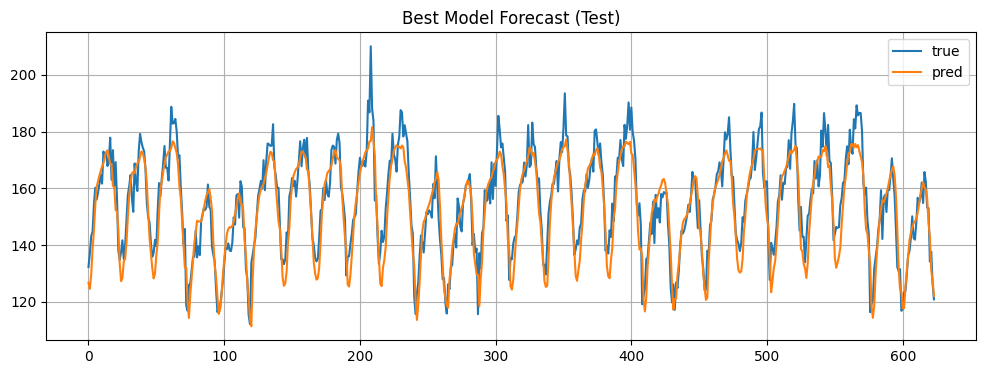

In [20]:
if "y_true" in globals() and "y_pred" in globals():
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label="true")
    plt.plot(y_pred, label="pred")

    plt.legend()
    plt.title("Best Model Forecast (Test)")
    plt.grid()

    plt.savefig("artifacts/figures/best_forecast_test.png")
    plt.show()
else:
    print("No predictions available")

# Сохранение конфига GRU

In [21]:
# =========================
# Save GRU config
# =========================

config = {
    "window_size": window_size,
    "hidden_size": 32,
    "batch_size": batch_size,
    "lr": lr,
    "epochs": epochs,
    "seed": SEED,
    "scaler": "standard"
}

with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=4)